# Intro
The project explores the performance of a global furniture company during its peak season (November–January), uncovering insights into regional sales, product profitability. By analyzing traffic sources and customer behavior across devices, the study delivers actionable recommendations to strengthen marketing strategies and expand market share.







Dashboard

In [ ]:
# Connecting to Google BigQuery
!pip install --upgrade pandas-gbq google-cloud-bigquery -q

import pandas as pd
from google.colab import auth
from google.cloud import bigquery

auth.authenticate_user()

project_id = "data-analytics-mate"
client = bigquery.Client(project=project_id)

In [ ]:
# Writing SQL
query = """
SELECT s.date,
       s.ga_session_id AS session_id,
       sp.continent,
       sp.country,
       sp.device,
       sp.browser,
       sp.mobile_model_name,
       sp.operating_system,
       sp.language AS browser_language,
       sp.name AS traffic_source,
       sp.channel AS traffic_channel,
       a.is_verified,
       a.id AS is_registered_user,
       a.is_unsubscribed,
       p.category AS product_category,
       p.name AS product_name,
       p.price,
       p.short_description


 FROM `data-analytics-mate.DA.session` s
 LEFT JOIN `DA.session_params` sp
 ON s.ga_session_id = sp.ga_session_id
 LEFT JOIN `DA.account_session` acs
 ON s.ga_session_id = acs.ga_session_id
 LEFT JOIN `DA.account` a
 ON acs.account_id = a.id
 LEFT JOIN `DA.order` o
 ON s.ga_session_id = o.ga_session_id
 LEFT JOIN `DA.product` p
 ON o.item_id = p.item_id
 """
sales = client.query(query).to_dataframe()
sales.head()

,date,session_id,continent,country,device,browser,mobile_model_name,operating_system,browser_language,traffic_source,traffic_channel,is_verified,is_registered_user,is_unsubscribed,product_category,product_name,price,short_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,(organic),Organic Search,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(direct),Direct,<NA>,<NA>,<NA>,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(direct),Direct,<NA>,<NA>,<NA>,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


In [ ]:
# Info by dataset

print("\Data type:")
sales.info()

<>:3: SyntaxWarning: invalid escape sequence '\D'
<>:3: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_3789/2343089462.py:3: SyntaxWarning: invalid escape sequence '\D'
  print("\Data type :")


\Data type :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   date                349545 non-null  dbdate 
 1   session_id          349545 non-null  Int64  
 2   continent           349545 non-null  object 
 3   country             349545 non-null  object 
 4   device              349545 non-null  object 
 5   browser             349545 non-null  object 
 6   mobile_model_name   349545 non-null  object 
 7   operating_system    349545 non-null  object 
 8   browser_language    235279 non-null  object 
 9   traffic_source      349545 non-null  object 
 10  traffic_channel     349545 non-null  object 
 11  is_verified         27945 non-null   Int64  
 12  is_registered_user  27945 non-null   Int64  
 13  is_unsubscribed     27945 non-null   Int64  
 14  product_category    33538 non-null   object 
 15  product_name        3

#Exploratory data analysis (EDA)

In [ ]:
#Changing data types
sales['date'] = pd.to_datetime(sales['date'])

#Define categorical columns
category_columns = [ "continent", "country", "device", "browser", "mobile_model_name", "operating_system", "browser_language", "traffic_source", "traffic_channel", "product_category" ]
sales[category_columns] = sales[category_columns].astype("category")
sales["product_name"] = sales["product_name"].astype("object")
sales["short_description"] = sales["short_description"].astype("object")

# Boolean columns
sales["is_verified"] = sales["is_verified"].astype("boolean")
sales["is_unsubscribed"] = sales["is_unsubscribed"].astype("boolean")

# Exploring dataset details
print("\nMemory usage of DataFrame:")
sales.info(memory_usage="deep")

unique_sessions = sales["session_id"].nunique()
print(f"Number of unique sessions: {unique_sessions}")

start_date = sales["date"].min()
end_date = sales["date"].max()
print(f"Period from {start_date} to {end_date}")

# Dataset information
print(f"Dataset shape:{sales.shape}")   # number of rows and columns
print(f"\nData types:\n{sales.dtypes}")
print(f"\nMissing values per column:\n{sales.isnull().sum()}")
print(f"\nDuplicated valuse:\n{sales.duplicated().sum()}")
print(f"\nBasic statistics for numeric columns:\n{sales.describe()}")
print(f"\nBasic statistics for category columns:\n{sales.describe(include="category")}")


# Columns grouped by type
data_types = {"numeric":"number","categorical":"category","boolean":"boolean","datetime":"datetime","text":"object"}
print("\nColumns grouped by type:")
for label, dtype in data_types.items():
    cols = sales.select_dtypes(include=dtype).columns.tolist()
    print(f"- {label.capitalize()}({len(cols)}): {cols}")




Memory usage of DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   date                349545 non-null  datetime64[ns]
 1   session_id          349545 non-null  Int64         
 2   continent           349545 non-null  category      
 3   country             349545 non-null  category      
 4   device              349545 non-null  category      
 5   browser             349545 non-null  category      
 6   mobile_model_name   349545 non-null  category      
 7   operating_system    349545 non-null  category      
 8   browser_language    235279 non-null  category      
 9   traffic_source      349545 non-null  category      
 10  traffic_channel     349545 non-null  category      
 11  is_verified         27945 non-null   boolean       
 12  is_registered_user  27945 non-null   Int64         
 13  i

#Exploratory data analysis (EDA)
###__Dataset size & scope:__

- 349 545 rows and 18 columns.

- Covers sessions between Nov 1, 2020 and Jan 31, 2021.

- Memory usage: ~39.6 MB.

- Unique sessions: 349 545 (each session_id is unique).
###__Data types:__

- _Numeric:_ __3__ (session_id, is_registered_user, price).

- _Categorical:_ __10__ (mobile_model_name, operating_system,browser_language, traffic_source, traffic_channel, product_category, continent, country, device, browser).

- _Boolean:_ __2__ (is_verified, is_unsubscribed).

- _Datetime:_ __1__ (date).

- _Text:_ __2__ (product_name, short_description).

### __Missing values__
- __is_verified / is_registered_user / is_unsubscribed__ (92% mssing)
These fields are populated only for accounts with explicit registration activity. The large proportion of missing values suggests that the majority of sessions are anonymous visitors or onetime users who never created an account. The dataset is heavily skewed toward non-registered traffic, which may affect analyses of retention or churn.

- __Product-related fields__(90% missing)
These columns are filled only when a session involves a product view or transaction. The high missingness indicates that most sessions are browsing or landing visits without product interaction. This is typical in e-commerce, where a large share of traffic comes from search engines or ads but does not proceed to product detail pages or purchases.

- __browser_language__ (33% missing)  
Missing values here likely reflect sessions where the browser did not send language metadata, or where tracking scripts failed to capture it. This can be common with privacy focused browsers, mobile apps, or bot traffic. It may also suggest technical limitations in data collection rather than user behavior.

###__Duplicates:__

- No duplicated rows detected.

###__Numeric statistics:__

- session_id: wide range, essentially an identifier, not analytically meaningful.

- is_registered_user: This looks like a user ID rather than a metric.

- price:

- Count: 33 538 (only ~10% of sessions involve a product with price).

 - Range: 3-9 585

- Median: 445 mean: 953 std: 1 317

 Distribution is right-skewed: most products are relatively low-priced, but a few high-end items inflate the mean.

###__Categorical statistics:__

- Continent: 6 categories, dominated by Americas (~55%)

- Country: 108 categories, top is United States (~44%)

- Device: 3 categories, dominated by desktop (~58%)

- Browser: 6 categories, top is Chrome (~68%)

- Operating system: 6 categories, top is Web(~58%)

- Traffic source/channel: 5 categories each, dominated by Organic Search(~34%)

- Product category: 14 categories, top is Bookcases & shelving units(~22%)

#Sales analysis by countries and continents


#Analytics by continent
  
- Which continents generate the highest revenue?

- What is the order volume in the top three continents ranked by revenue?

- How does the Average Order Value (AOV) compare across these top continents?

- What are the conversion rates in these continents, and how do they relate to revenue and order volume?




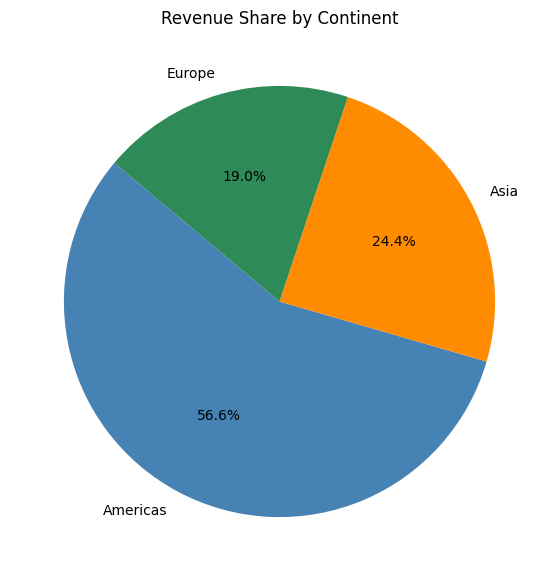

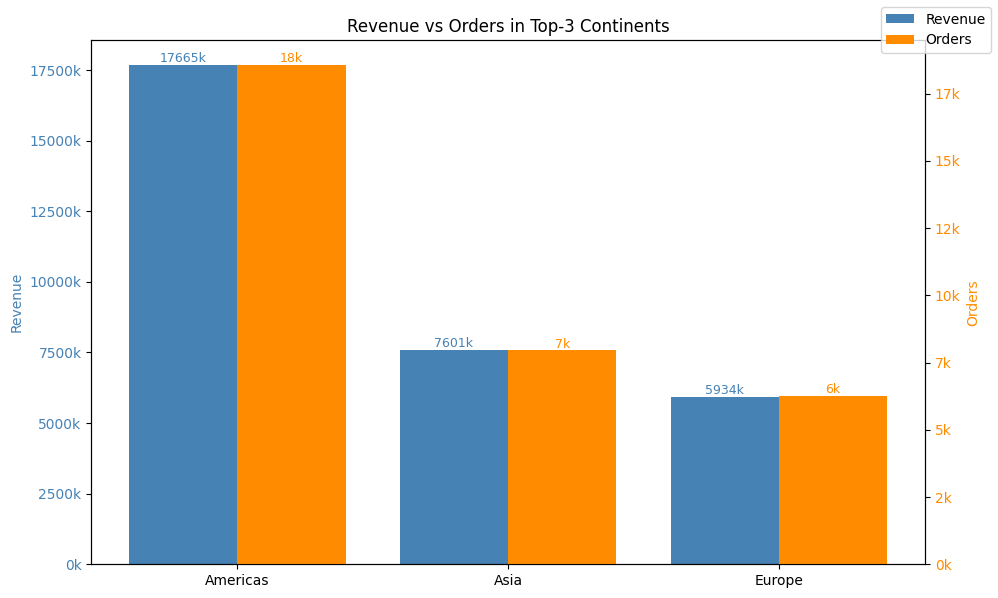

Revenue by continent:
continent
Americas     17665280.0
Asia          7601298.3
Europe        5934624.2
Oceania        365230.2
Africa         331231.0
(not set)       74067.4
Name: price, dtype: float64

Average Order Value by Continent:
continent
(not set)    1043.202817
Oceania      1003.379670
Africa        977.082596
Asia          956.138151
Americas      952.152213
Europe        947.871618
Name: price, dtype: float64

Average Order Value by TOP 3 Continent:
 continent
Americas    952.152213
Asia        956.138151
Europe      947.871618
Name: price, dtype: float64

Conversion Rate by Continent:
 continent
Oceania      0.098299
Europe       0.096123
Americas     0.096040
Asia         0.095653
Africa       0.093646
(not set)    0.089308
dtype: float64


/tmp/ipython-input-1810481570.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conversion_by_continent = sales.groupby("continent", observed=True).apply(lambda x: x["price"].notna().mean()).sort_values(ascending=False)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd




# Top-3 Continent by revenue
top_3_continent_by_revenue = sales.groupby("continent",observed=True)["price"].sum().nlargest(3)
top_3_continent_by_orders = sales.groupby("continent",observed=True)["product_name"].count().loc[top_3_continent_by_revenue.index]
# Pie chart by TOP continent
plt.figure(figsize=(7,7))
plt.pie(top_3_continent_by_revenue,labels=top_3_continent_by_revenue.index,autopct="%1.1f%%",startangle=140,colors=["steelblue", "darkorange", "seagreen", "purple", "gold"])
plt.title("Revenue Share by Continent")
plt.show()



# Create DataFrame (revenue+orders by top 3 continent)
comparison_df = pd.DataFrame({"Revenue": top_3_continent_by_revenue,"Orders": top_3_continent_by_orders})
continents = comparison_df.index
x = np.arange(len(continents))
fig, ax1 = plt.subplots(figsize=(10,6))

import matplotlib.ticker as mticker

# Revenue (Left)
bars1 = ax1.bar(x - 0.2, comparison_df["Revenue"], width=0.4, color="steelblue", label="Revenue")
ax1.set_ylabel("Revenue", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Format K for Revenue
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v/1000)}k'))

# Orders (right)
ax2 = ax1.twinx()
bars2 = ax2.bar(x + 0.2, comparison_df["Orders"], width=0.4, color="darkorange", label="Orders")
ax2.set_ylabel("Orders", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# Format K for Orders
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v/1000)}k'))

# value for revenue & orders
ax1.bar_label(bars1, labels=[f'{int(v/1000)}k' for v in comparison_df["Revenue"]], label_type="edge", fontsize=9, color="steelblue")
ax2.bar_label(bars2, labels=[f'{int(v/1000)}k' for v in comparison_df["Orders"]], label_type="edge", fontsize=9, color="darkorange")

ax1.set_xticks(x)
ax1.set_xticklabels(continents)
plt.title("Revenue vs Orders in Top-3 Continents")
fig.legend(loc="upper right", facecolor="white")
plt.tight_layout()
plt.show()



# Revenue by all continent
continent_by_revenue = sales.groupby("continent",observed=True)["price"].sum().sort_values(ascending=False)
print(f"Revenue by continent:\n{continent_by_revenue}\n")

#Average Order by continent
aov_continents = sales.groupby("continent", observed=True)["price"].mean().sort_values(ascending=False)
print(f"Average Order Value by Continent:\n{aov_continents}\n")

#AOV TOP 3 continent
aov_top_3 = aov_continents.loc[top_3_continent_by_revenue.index]
print(f"Average Order Value by TOP 3 Continent:\n {aov_top_3}\n")

# Conversion by continent (session/session with orders)
conversion_by_continent = sales.groupby("continent", observed=True).apply(lambda x: x["price"].notna().mean()).sort_values(ascending=False)
print("Conversion Rate by Continent:\n", conversion_by_continent)


#Bisness recomendation
Americas generate the highest revenue thanks to a significantly larger number of orders, even though their average order value and conversion rate are similar to other regions.

Europe could become more competitive if it focuses on increasing order volume, since its conversion rate is already the highest.

Asia balances between the two approaches but lags behind the Americas in scale. It has growth potential if it improves its conversion rate.


# Analytics by countries
-  Is a country’s revenue driven by order volume or by premium average order value?
- Which countries have a premium average order value?
- Where is the audience most engaged (high conversion rate)?

In [ ]:


#TOP 10 countries by revenue
top_10_countries_by_revenue = sales.groupby("country", observed=True)["price"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 countries by revenue:\n", top_10_countries_by_revenue)

#TOP 10 countries by orders
top_10_country_by_orders = sales.groupby("country",observed=True)["product_name"].count().sort_values(ascending=False).head(10)
print(f"\nTop 10 country by orders:\n {top_10_country_by_orders}\n")

#AOV TOP 10 Countries
aov_countries = sales.groupby("country", observed=True)["price"].mean().loc[top_10_countries_by_revenue.index].sort_values(ascending=False)
print("\nAverage Order Value by Top-10 Countries:\n", aov_countries)

#Conversion by country (session/session with orders)
conversion_by_country= sales.groupby("country", observed=True).apply(lambda x: x["price"].notna().mean()).sort_values(ascending=False)
conversion_by_top_10_country = conversion_by_country.loc[top_10_countries_by_revenue.index].sort_values(ascending=False)
print("\nConversion Rate by TOP 10 Countries :\n", conversion_by_top_10_country)




Top 10 countries by revenue:
 country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Spain               631546.7
Germany             599221.4
China               588329.6
Taiwan              552710.3
Singapore           456447.2
Name: price, dtype: float64

Top 10 country by orders:
 country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
Spain               658
Germany             642
China               600
Taiwan              564
Japan               454
Name: product_name, dtype: int64


Average Order Value by Top-10 Countries:
 country
France            1048.219469
Singapore         1005.390308
China              980.549333
Taiwan             979.982801
Spain              959.797416
Canada             952.312891
United States      950.286506
Germany            933.366667
India              927.620337
United Kingd

/tmp/ipython-input-2499171869.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conversion_by_country= sales.groupby("country", observed=True).apply(lambda x: x["price"].notna().mean()).sort_values(ascending=False)


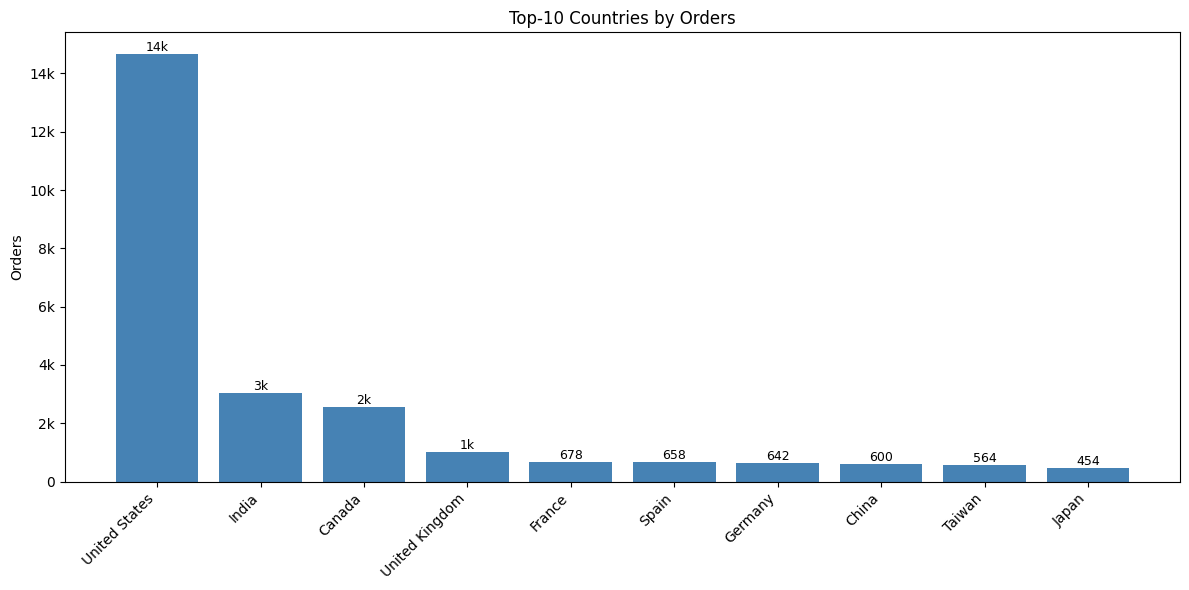

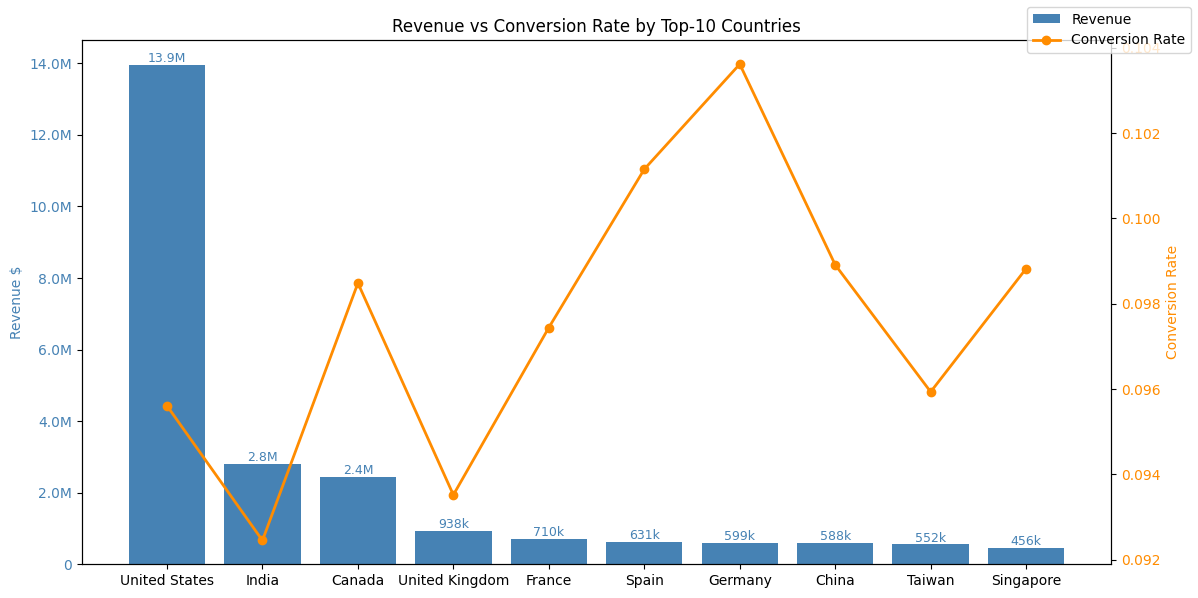

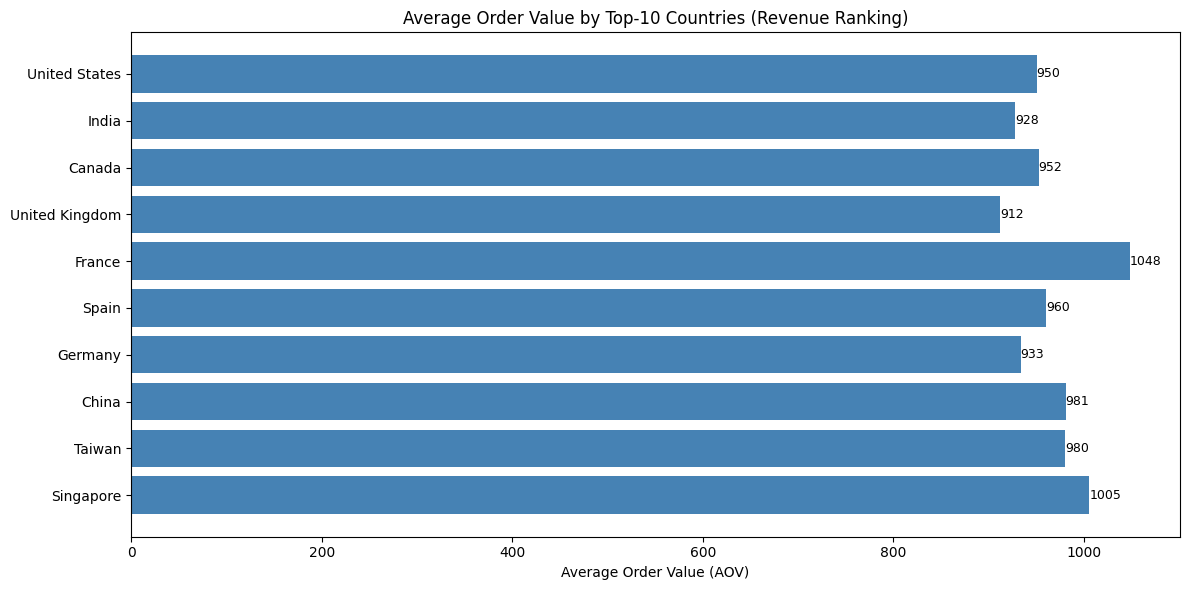

In [ ]:

import matplotlib.ticker as mticker

# Format func
def format_number(v):
    if v < 1000:
        return f'{int(v)}'
    elif v < 1e6:
        return f'{int(v/1000)}k'
    else:
        return f'{v/1e6:.1f}M'

# Visualization orders
orders = top_10_country_by_orders
plt.figure(figsize=(12,6))
bars = plt.bar(orders.index, orders.values, color="steelblue")

# ax Y
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: format_number(v)))

# Bar label
plt.bar_label(bars, labels=[format_number(v) for v in orders.values],label_type="edge", fontsize=9, color="black")
plt.ylabel("Orders")
plt.title("Top-10 Countries by Orders")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()






#---Visualization Revenue & Conversion Rate top 10 countries---

# Format func
def format_number(v):
    if v < 1000:
        return f'{int(v)}'
    elif v < 1e6:
        return f'{int(v/1000)}k'
    else:
        return f'{v/1e6:.1f}M'

countries = top_10_countries_by_revenue.index
revenues = top_10_countries_by_revenue.values
conversions = conversion_by_top_10_country.reindex(countries).values

fig, ax1 = plt.subplots(figsize=(12,6))

# Revenue (bars)
bars = ax1.bar(countries, revenues, color="steelblue", label="Revenue")
ax1.set_ylabel("Revenue $", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Format for Revenue
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: format_number(v)))

# Conversion Rate (line)
ax2 = ax1.twinx()
ax2.plot(countries, conversions, color="darkorange", marker="o", linewidth=2, label="Conversion Rate")
ax2.set_ylabel("Conversion Rate", color="darkorange")
ax2.tick_params(axis="y", labelcolor="darkorange")

# value labels  Revenue
ax1.bar_label(bars, labels=[format_number(v) for v in revenues],label_type="edge", fontsize=9, color="steelblue")
plt.title("Revenue vs Conversion Rate by Top-10 Countries")
fig.legend(loc="upper right", facecolor="white")
plt.tight_layout()
plt.show()



#Vizualization AOV (Horizontal bar chart)
countries = top_10_countries_by_revenue.index
aov_values = aov_countries.reindex(countries).values

#Horizontal bar chart
plt.figure(figsize=(12,6))
bars = plt.barh(countries, aov_values, color="steelblue")

#value
plt.bar_label(bars, fmt="%.0f", label_type="edge", fontsize=9, color="black")
plt.xlabel("Average Order Value (AOV)")
plt.title("Average Order Value by Top-10 Countries (Revenue Ranking)")
plt.gca().invert_yaxis()  # Top AOV country
plt.tight_layout()
plt.show()




# Business recomendation

__1. Scale-driven markets (Revenue through order volume):__

__United States, India, Canada__ -Their revenue is generated primarily by a large number of orders, while their AOV remains mid-range.

__Recommendation:__ Focus on logistics optimization and sustaining scale. Test premium segments to gradually increase AOV.

__2. Premium markets (Revenue through high AOV):__

__France, Singapore, China, Taiwan__ - Fewer orders, but high average order value (~980-1048).

__Recommendation:__ Expand premium offerings and strengthen marketing toward high-spending customer segments.

__3. High-engagement markets (Conversion Rate):__

__Germany (0.104), Spain (0.101)__ - Highest conversion rates, meaning customers are more likely to complete purchases.

__Recommendation:__ Invest in scaling these markets by boosting order volume through marketing campaigns and product diversification.

__4. Growth potential markets:__

__India__ - Large order volume but low AOV and the lowest conversion rate (0.092).

__Recommendation:__ Work on increasing AOV via upselling/cross-selling and improve the purchase process to raise conversion.

__5. United States as a strategic driver:__

Revenue leader (~13.9M) due to scale.

__Recommendation:__ Maintain leadership while exploring opportunities to raise AOV and conversion, reducing reliance on sheer volume.


#Analytics by category
- Which product categories generate the highest revenue?

- Which categories are the most popular in terms of order volume?

- Which categories dominate in the top-earning country?

- What is the right mix of premium and mass-segment products to optimize overall revenue performance?


TOP 10 categories by revenue:
product_category
Sofas & armchairs                   8388254.5
Chairs                              6147748.8
Beds                                4919725.0
Bookcases & shelving units          3640818.1
Cabinets & cupboards                2336499.5
Outdoor furniture                   2142222.2
Tables & desks                      1790307.5
Chests of drawers & drawer units     906562.5
Bar furniture                        735503.0
Children's furniture                 467697.0
Name: price, dtype: float64

TOP 10 categories by sold item:
product_category
Bookcases & shelving units          7630
Chairs                              5952
Sofas & armchairs                   4301
Tables & desks                      2941
Beds                                2926
Cabinets & cupboards                2318
Outdoor furniture                   2229
Children's furniture                1702
Chests of drawers & drawer units    1452
Bar furniture                       1092
Name

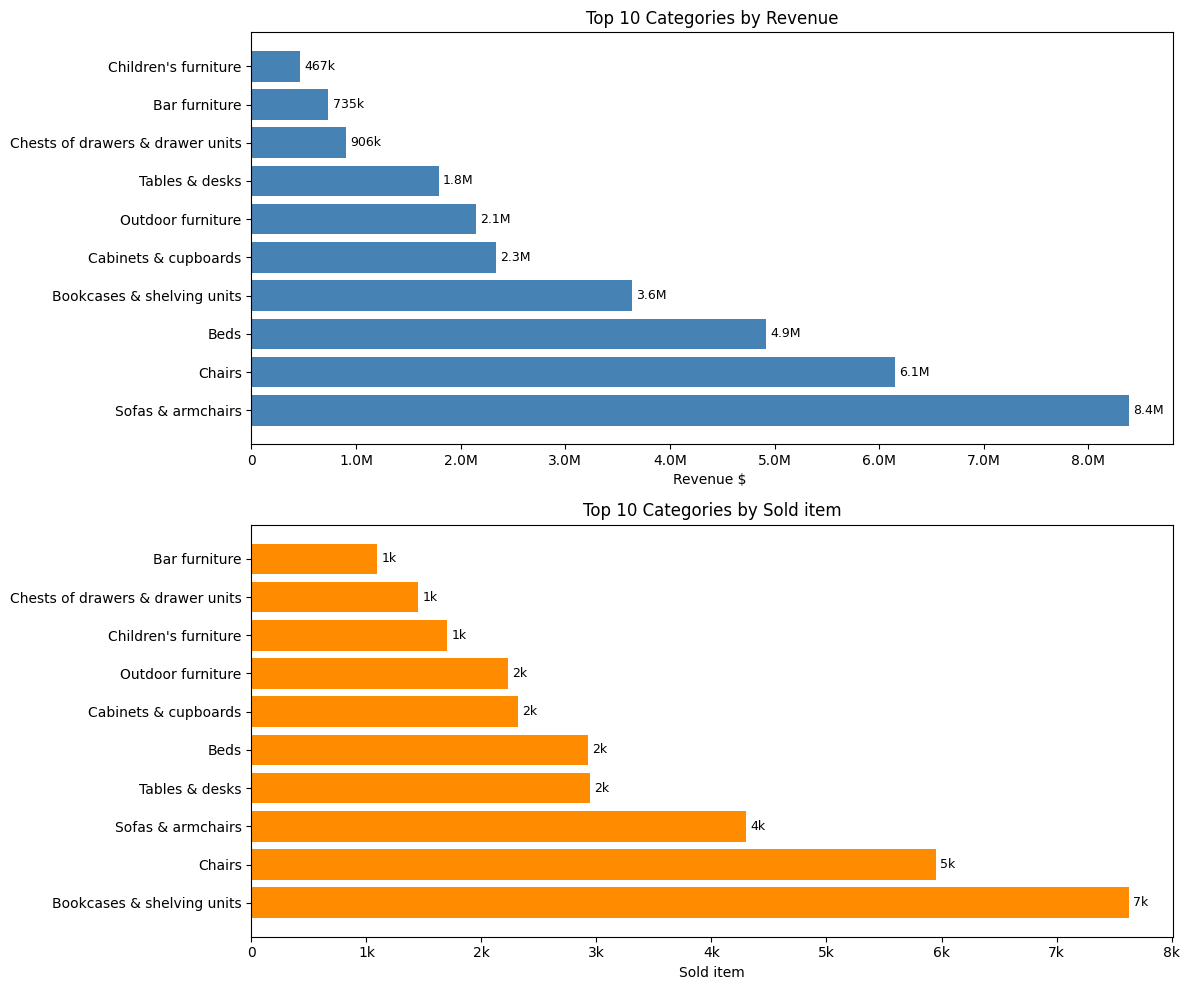


 Top 10 Categories by Revenue in USA:
product_category
Sofas & armchairs                   3707144.5
Chairs                              2619773.8
Beds                                2213058.0
Bookcases & shelving units          1567606.9
Cabinets & cupboards                 994545.5
Outdoor furniture                    929245.2
Tables & desks                       777865.0
Chests of drawers & drawer units     382388.0
Bar furniture                        330805.0
Children's furniture                 207575.0
Name: price, dtype: float64


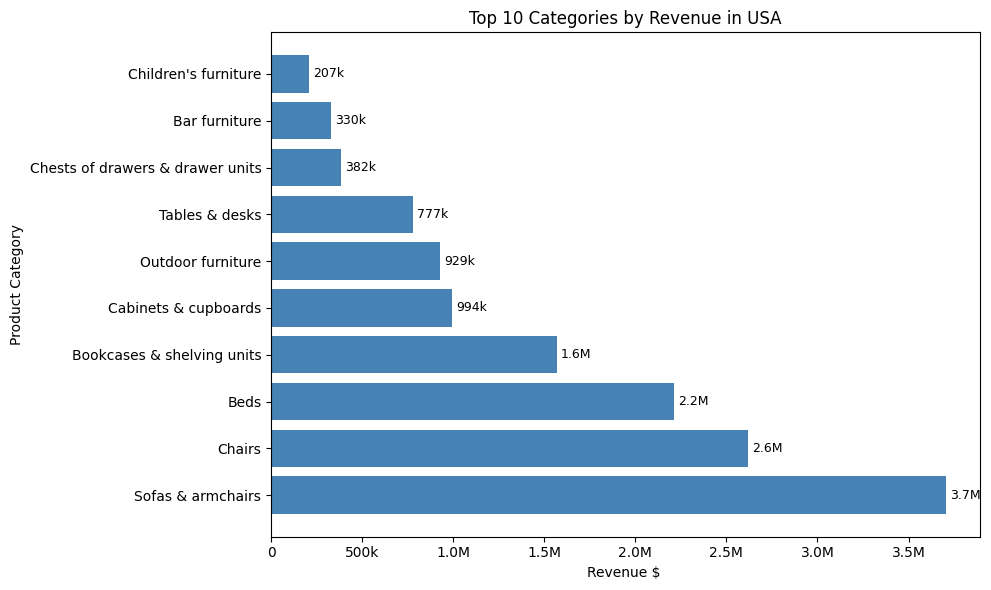

/tmp/ipython-input-2527416271.py:90: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_revenue = (sales[sales["country"].isin(top_10_countries_by_revenue.index)].pivot_table(index="product_category",columns="country",


Pivot table of Top-5 Categories by Revenue across Top-10 Countries:
 country                     United States     India    Canada  United Kingdom  \
product_category                                                                
Sofas & armchairs               3707144.5  788430.0  692427.5        234812.0   
Chairs                          2619773.8  544309.2  417740.8        188519.4   
Beds                            2213058.0  358319.5  354772.0        133816.0   
Bookcases & shelving units      1567606.9  364507.4  278981.9        113987.6   
Cabinets & cupboards             994545.5  191888.0  181802.0         71684.5   

country                       France     Spain   Germany     China    Taiwan  \
product_category                                                               
Sofas & armchairs           187735.0  180660.5  147632.5  144430.0  126981.0   
Chairs                      134029.4  122558.2  123979.0  130800.0  121097.0   
Beds                        116414.0   8633

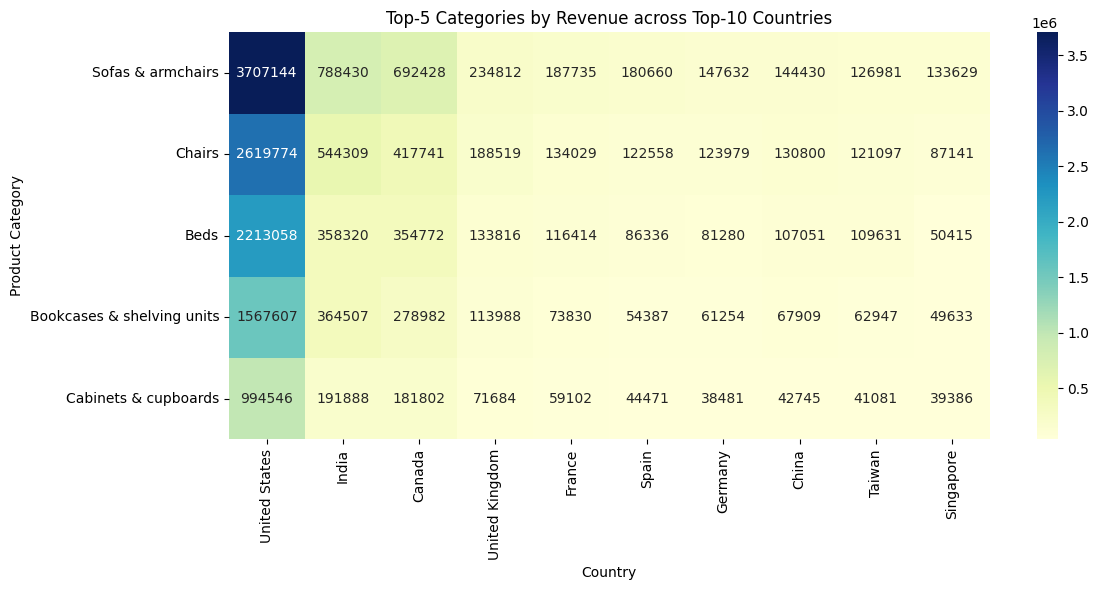

Difference between AOV & Median by TOP 10 Categories (revenue):
                   product_category          AOV  Median  Difference
8                 Sofas & armchairs  1950.303302  1176.0  774.303302
1                              Beds  1681.382433  1095.0  586.382433
4                            Chairs  1032.887903   395.0  637.887903
3              Cabinets & cupboards  1007.980802   841.0  166.980802
7                 Outdoor furniture   961.068730   356.0  605.068730
0                     Bar furniture   673.537546   435.0  238.537546
5  Chests of drawers & drawer units   624.354339   460.0  164.354339
9                    Tables & desks   608.741074   376.0  232.741074
2        Bookcases & shelving units   477.171442   235.0  242.171442
6              Children's furniture   274.792597   195.0   79.792597


/tmp/ipython-input-2527416271.py:155: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(loc="lower right")


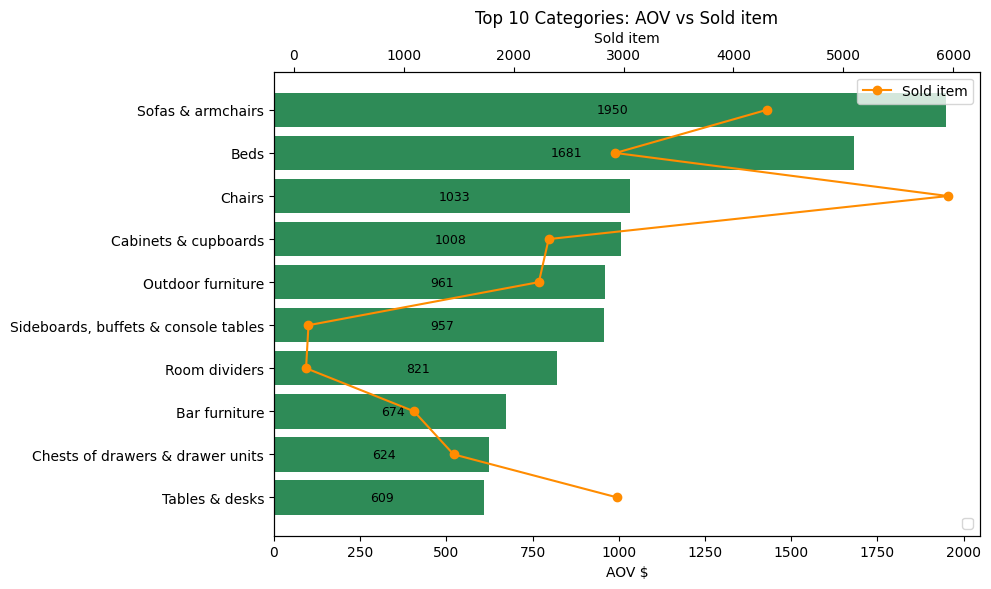

In [ ]:
import seaborn as sns

#TOP 10 catigories by revenue
top_10_categories_by_revenue= sales.groupby("product_category",observed=True)["price"].sum().sort_values(ascending=False).head(10)
print(f"\nTOP 10 categories by revenue:\n{top_10_categories_by_revenue}")

#TOP 10 category by Sold items
top_10_categories_by_sold_item = sales.groupby("product_category",observed=True)["product_name"].count().sort_values(ascending=False).head(10)
print(f"\nTOP 10 categories by sold item:\n{top_10_categories_by_sold_item}")




#---TOP 10 Categories Revenue & Sold item----

# Format func
def format_number(v):
    if v < 1000:
        return f'{int(v)}'
    elif v < 1e6:
        return f'{int(v/1000)}k'
    else:
        return f'{v/1e6:.1f}M'

rev = top_10_categories_by_revenue
ordr = top_10_categories_by_sold_item

fig, axes = plt.subplots(2, 1, figsize=(12,10))

# Revenue horizontal chart
bars_rev = axes[0].barh(rev.index, rev.values, color="steelblue")
axes[0].set_title("Top 10 Categories by Revenue")
axes[0].set_xlabel("Revenue $ ")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: format_number(v)))
axes[0].bar_label(bars_rev, labels=[format_number(v) for v in rev.values],label_type="edge", fontsize=9, color="black", padding=3)

# Orders horizontal chart
bars_ordr = axes[1].barh(ordr.index, ordr.values, color="darkorange")
axes[1].set_title("Top 10 Categories by Sold item")
axes[1].set_xlabel("Sold item")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: format_number(v)))
axes[1].bar_label(bars_ordr, labels=[format_number(v) for v in ordr.values],label_type="edge", fontsize=9, color="black", padding=3)

plt.tight_layout()
plt.show()






#----TOP 10 categories in USA----
def format_number(v):
    if v < 1000:
        return f'{int(v)}'
    elif v < 1e6:
        return f'{int(v/1000)}k'
    else:
        return f'{v/1e6:.1f}M'

# Filter data
sales_usa = sales[sales["country"] == "United States"]

# TOP 10 categories in USA
top_10_categories_USA_by_revenue = (sales_usa.groupby("product_category", observed=True)["price"].sum().sort_values(ascending=False).head(10))

print(f"\n Top 10 Categories by Revenue in USA:\n{top_10_categories_USA_by_revenue}")

# Visualization
plt.figure(figsize=(10,6))
bars = plt.barh(top_10_categories_USA_by_revenue.index,top_10_categories_USA_by_revenue.values,color="steelblue")
plt.title("Top 10 Categories by Revenue in USA")
plt.xlabel("Revenue $ ")
plt.ylabel("Product Category")

# X
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: format_number(v)))

# Bar label
plt.bar_label(bars,labels=[format_number(v) for v in top_10_categories_USA_by_revenue.values],label_type="edge", fontsize=9, color="black", padding=3)
plt.tight_layout()
plt.show()






# Pivot: category × country, value = revenue
pivot_revenue = (sales[sales["country"].isin(top_10_countries_by_revenue.index)].pivot_table(index="product_category",columns="country",
                                                                                             values="price",aggfunc="sum",fill_value=0))

# Sort rows and columns by revenue
pivot_revenue = pivot_revenue.loc[pivot_revenue.sum(axis=1).sort_values(ascending=False).index]
pivot_revenue = pivot_revenue[pivot_revenue.sum(axis=0).sort_values(ascending=False).index]
# Onlly ТOP ‑10 countries
pivot_revenue = pivot_revenue[top_10_countries_by_revenue.index]
# TOP 5 category(revenue) in TOP 10 countries(revenue)
pivot_revenue_top5 = pivot_revenue.head(5)
print("Pivot table of Top-5 Categories by Revenue across Top-10 Countries:\n", pivot_revenue_top5)

#Visualization
# heatmap by pivot Top-5 Categories by Revenue across Top-10 Countries
plt.figure(figsize=(12,6))
sns.heatmap(pivot_revenue_top5, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Top-5 Categories by Revenue across Top-10 Countries")
plt.xlabel("Country")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()




#-----AOV & Median----
# top 10 categories
top_10_categories_by_revenue = sales.groupby("product_category",observed=True)["price"].sum().reset_index().sort_values(by="price", ascending=False).head(10)["product_category"]

# Filter
top10_data = sales[sales["product_category"].isin(top_10_categories_by_revenue)]

#  AOV, Median, Difference
stats_top10 = top10_data.groupby("product_category",observed=True)["price"].agg(AOV="mean", Median="median").reset_index()
stats_top10["Difference"] = stats_top10["AOV"] - stats_top10["Median"]

print(f"Difference between AOV & Median by TOP 10 Categories (revenue):\n{stats_top10.sort_values(by='AOV', ascending=False)}")



# ----AOV----

# Revenue and Orders by categories
category_revenue = sales.groupby("product_category",observed=True)["price"].sum()
category_sold_items = sales.groupby("product_category",observed=True)["product_name"].count()
#(AOV)
category_aov = category_revenue / category_sold_items



# Visualization
top_categories = category_aov.sort_values(ascending=False).head(10).index
aov_top = category_aov.loc[top_categories]
orders_top = category_sold_items.loc[top_categories]
fig, ax1 = plt.subplots(figsize=(10,6))
# Bar chart AOV
bars = ax1.barh(aov_top.index, aov_top.values, color="seagreen")
ax1.set_xlabel("AOV $")
ax1.set_title("Top 10 Categories: AOV vs Sold item")
plt.bar_label(bars, fmt="%.0f", label_type="center", fontsize=9, color="black",padding= 2)
ax1.invert_yaxis()
# Sold item line
ax2 = ax1.twiny()
ax2.plot(orders_top.values, aov_top.index, "o-", color="darkorange", label="Sold item")
ax2.set_xlabel("Sold item")
ax1.legend(loc="lower right")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.show()



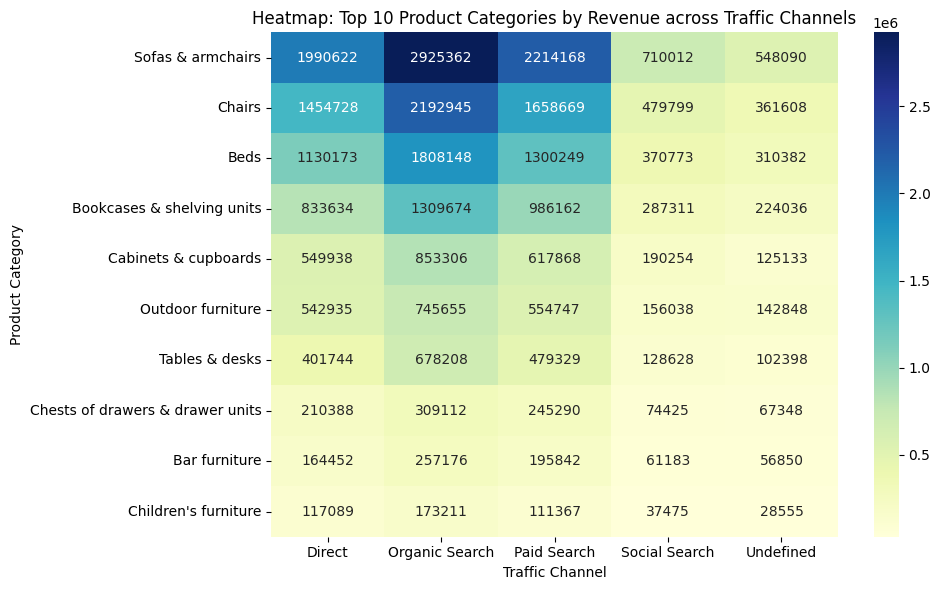

In [ ]:
# ---Categories by traffic channel---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Group category ny traffic channel
category_by_channel = (sales.groupby(["product_category", "traffic_channel"],observed=True).agg(Revenue=("price", "sum"), Orders=("product_name", "count")).reset_index())

#TOP 10 categories by revenue
top10_categories = category_by_channel.groupby("product_category",observed=True)["Revenue"].sum().sort_values(ascending=False).head(10).index
top10_data = category_by_channel[category_by_channel["product_category"].isin(top10_categories)]

# Pivot (Revenue)
heatmap_data = top10_data.pivot(index="product_category", columns="traffic_channel", values="Revenue")
# Sort velues categories by revenue
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data,annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Heatmap: Top 10 Product Categories by Revenue across Traffic Channels")
plt.ylabel("Product Category")
plt.xlabel("Traffic Channel")
plt.tight_layout()
plt.show()



# Business recomendation
__Categories generate the highest :__

- Sofas & armchairs (~ $8.39M)

- Chairs (~ $6.15M)

- Beds (~ $4.92M)

- Bookcases & shelving units (~ $3.64M)

 These are the major furniture categories that form the core of revenue. They are the key revenue drivers, especially in the USA, where the same categories occupy the top positions.

 __Categories are the most popular by number of orders:__

- Bookcases & shelving units (~ 7 630 units)

- Chairs (~ 5 952 units)

- Sofas & armchairs (~ 4 301 units)

- Tables & desks (~ 2 941 units)

Popularity does not always correlate with revenue: for example, Bookcases & shelving units have the highest sales volume in units but a lower average order value. This is a mass-market segment that drives volume but not maximum revenue.

__Categories dominate in the top country (USA):__

- Sofas & armchairs (~ $3.71M)

- Chairs (~ $2.62M)

- Beds (~ $2.21M)

- Bookcases & shelving units (~ $1.57M)

 In the USA, the revenue structure mirrors the global picture: premium categories (sofas, beds) combined with mass-market ones (chairs, bookcases). This confirms that the strategy needs to be balanced.

__the right mix of premium and mass-market categories:__

_Premium:_ Sofas & armchairs (AOV ~ $1 950), Beds (~ $1 681), Cabinets & cupboards (~ $1 008). These generate high revenue per order but have lower sales volumes.

__Role in the strategy:__
- Use for upselling and cross-selling after mas-market products.
- Position as “quality investments” for the home.
- Support and reinforce the premium brand image

 _Mass-market:_ Bookcases & shelving units (7 630 units, lower AOV), Chairs (5 952 units, AOV ~ $1 033). These ensure a steady flow of orders and a broad customer base.

__Role in the strategy:__
- Use as entry products to attract new customers.
- Promote through discounts, bundle offers, and cross-selling.
- Provide a broad customer base that can later be converted into the premium segment.

###Optimal balance:

_Mass-market products_ = attract and retain customers.

_Premium products_ = maximize margin and average order value.

__Mix:__

Mass-market categories should form the foundation of the assortment (~ 60-70% of unit sales).

Premium categories are the key revenue drivers (~ 40-50% of total revenue).

It is important to maintain cross-selling: for example, a customer buys a bookcase → receives an offer for a sofa or a bed.

### Trafffic Channel recomendation
__Focus on organic search:__ Invest in SEO and content, as organic search delivers the highest revenue across key product categories.

__Strengthen Paid Search for premium categories:__ Sofas, chairs, and beds show strong returns on advertising investment.

__Use Social as brand support:__ While revenue is lower, it can serve as a channel to attract new customers in lower-priced categories.


#Analytics by device
- Where is the main revenue generated?

- Which channel delivers the highest order volume?

- On which devices do customers purchase premium products, and on which do they buy mass-segment products?

- How should marketing and assortment be balanced across devices?


 Device by revenue:
    device       price  percentage
0  desktop  18864039.0       59.00
1   mobile  12384225.8       38.73
2   tablet    723466.3        2.26


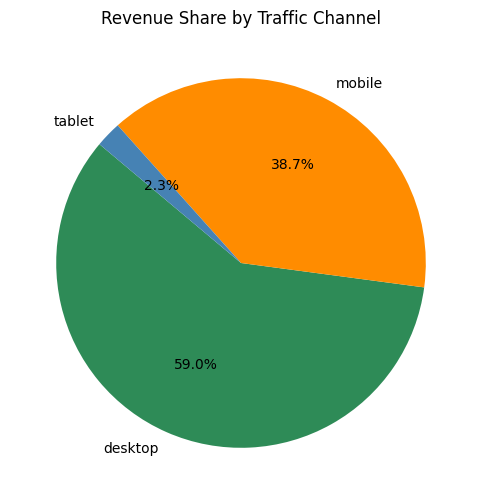

  traffic_channel  product_name  percentage
1  Organic Search         11921       35.54
2     Paid Search          9042       26.96
0          Direct          7800       23.26
3   Social Search          2716        8.10
4       Undefined          2059        6.14


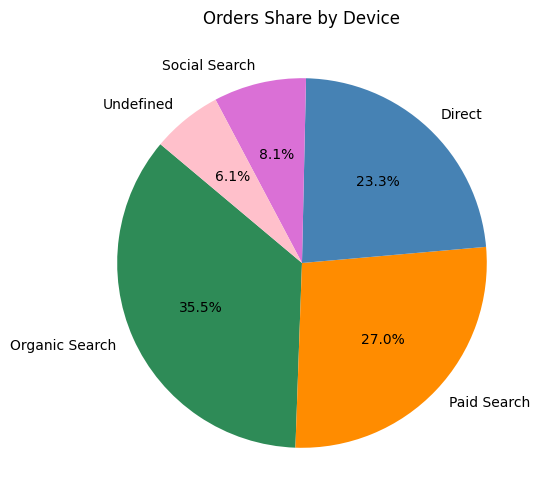

In [ ]:
#Revenue by device
revenue_by_device = sales.groupby("device", observed=True)["price"].sum().reset_index()
total_revenue = revenue_by_device["price"].sum()
revenue_by_device["percentage"] = (revenue_by_device["price"] / total_revenue * 100).round(2)
device_revenue = revenue_by_device.sort_values("percentage", ascending=False)

print(f"\n Device by revenue:\n{device_revenue}")

#Visualization pie chart
plt.figure(figsize=(6,6))
plt.pie( revenue_by_device["price"], labels=revenue_by_device["device"], autopct="%1.1f%%", startangle=140, colors=["seagreen", "darkorange", "steelblue", "orchid"])
plt.title("Revenue Share by Traffic Channel")
plt.show()

#Orders by device type
orders_by_traffic_channel = sales.groupby("traffic_channel", observed=True)["product_name"].count().reset_index()
total_orders = orders_by_traffic_channel["product_name"].sum()
orders_by_traffic_channel["percentage"] = (orders_by_traffic_channel["product_name"] / total_orders * 100).round(2)
orders_by_traffic_channel = orders_by_traffic_channel.sort_values(ascending=False, by="percentage")

print(orders_by_traffic_channel)

#Visualization pie chart
plt.figure(figsize=(6,6))
plt.pie( orders_by_traffic_channel["product_name"], labels=orders_by_traffic_channel["traffic_channel"], autopct="%1.1f%%", startangle=140, colors=["seagreen", "darkorange", "steelblue", "orchid","pink"])
plt.title("Orders Share by Device")
plt.show()








Premium segment by device:

Revenue:
device
desktop    9135493.5
mobile     6163018.0
tablet      345967.5
Name: price, dtype: float64

Orders:
device
desktop    5576
mobile     3762
tablet      207
Name: product_name, dtype: int64

AOV:
device
desktop    1638.36
mobile     1638.23
tablet     1671.34
dtype: float64

Mass segment by device:

Revenue:
device
desktop    5864240.4
mobile     3687770.5
tablet      236556.0
Name: price, dtype: float64

Orders:
device
desktop    7965
mobile     5322
tablet      295
Name: product_name, dtype: int64

AOV:
device
desktop    736.25
mobile     692.93
tablet     801.88
dtype: float64


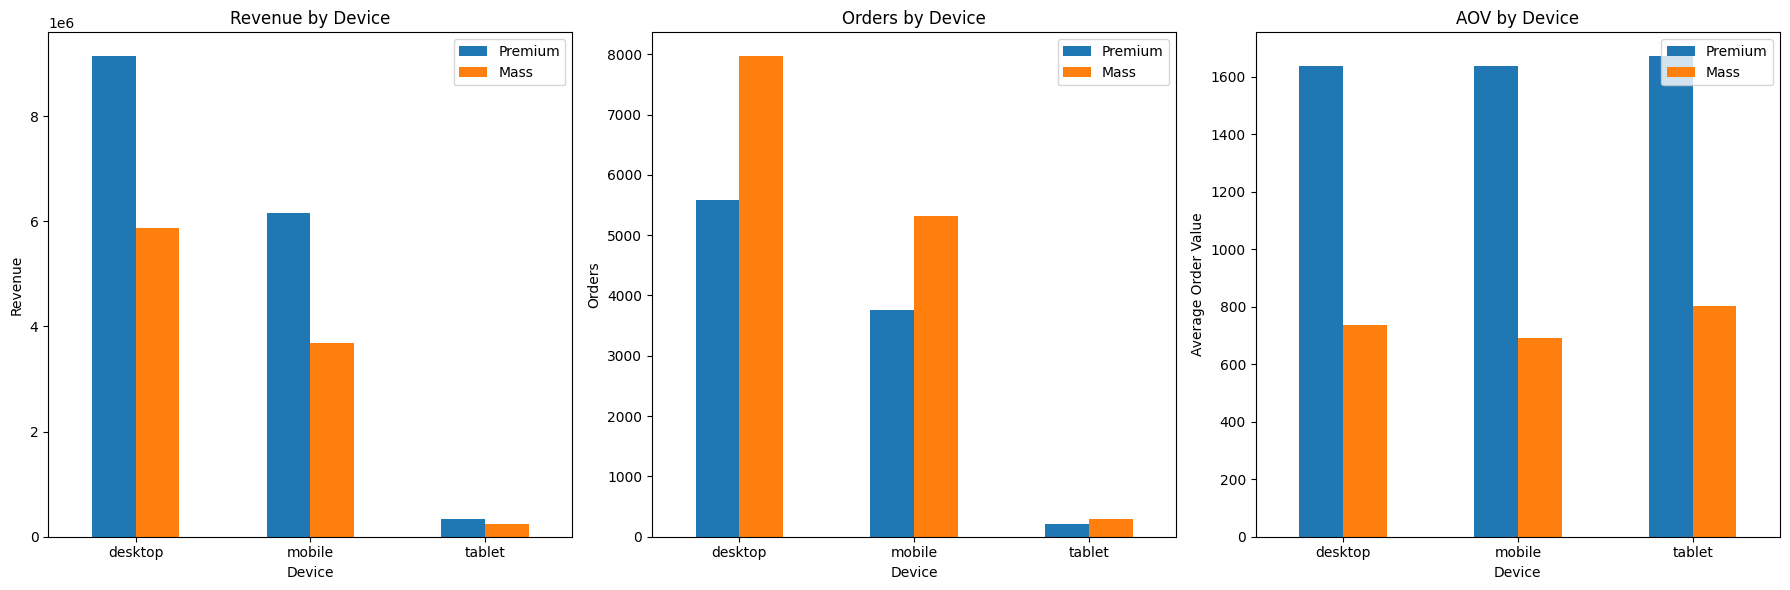

In [ ]:
#Define premium and mass‑market categories
premium_categories = ["Sofas & armchairs", "Beds", "Cabinets & cupboards"]
mass_categories = ["Bookcases & shelving units", "Chairs"]
#Filter data
sales_premium = sales[sales["product_category"].isin(premium_categories)]
sales_mass = sales[sales["product_category"].isin(mass_categories)]


# --- PREMIUM ---
#Revenue by device
revenue_premium = sales_premium.groupby("device",observed=True)["price"].sum()
#Orders by device (count not null product_name)
orders_premium = sales_premium[sales_premium["product_name"].notna()].groupby("device",observed=True)["product_name"].count()
#AOV by device
aov_premium = (revenue_premium / orders_premium).round(2)
#Check result
print(f"\nPremium segment by device:")
print(f"\nRevenue:\n{revenue_premium}")
print(f"\nOrders:\n{orders_premium}")
print(f"\nAOV:\n{aov_premium}")



# --- MASS ---
# Revenue by device
revenue_mass = sales_mass.groupby("device",observed=True)["price"].sum()
# Orders by device
orders_mass = sales_mass[sales_mass["product_name"].notna()].groupby("device",observed=True)["product_name"].count()
# AOV by device
aov_mass = (revenue_mass / orders_mass).round(2)

#Check result
print(f"\nMass segment by device:")
print(f"\nRevenue:\n{revenue_mass}")
print(f"\nOrders:\n{orders_mass}")
print(f"\nAOV:\n{aov_mass}")





# Create DF
df_revenue = pd.DataFrame({"Premium": revenue_premium,"Mass": revenue_mass})
df_orders = pd.DataFrame({"Premium": orders_premium,"Mass": orders_mass})
df_aov = pd.DataFrame({"Premium": aov_premium,"Mass": aov_mass})

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Revenue
df_revenue.plot(kind="bar", ax=axes[0])
axes[0].set_title("Revenue by Device")
axes[0].set_ylabel("Revenue")
axes[0].set_xlabel("Device")
axes[0].tick_params(axis='x', rotation=0)

# Orders
df_orders.plot(kind="bar", ax=axes[1])
axes[1].set_title("Orders by Device")
axes[1].set_ylabel("Orders")
axes[1].set_xlabel("Device")
axes[1].tick_params(axis='x', rotation=0)

# AOV
df_aov.plot(kind="bar", ax=axes[2])
axes[2].set_title("AOV by Device")
axes[2].set_ylabel("Average Order Value")
axes[2].set_xlabel("Device")
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()



# Business recomendation

The main revenue is generated on __desktop__, which accounts for nearly 60% of total sales.

The highest order volume is also on __desktop__ but mobile holds a significant share (~39%).


Premium products are purchased mainly on desktop (higher revenue and consistently high AOV).
Mass‑market products are also stronger on desktop, but mobile holds a significant share of orders (volume purchases with a lower average check).

- Desktop:

Focus on the premium segment: detailed product pages, upselling, financing options, and cross‑selling. This is the channel for high‑margin products.

- Mobile:

Promote mass‑market products: discounts, quick deals, and bundles. This is the channel for driving volume and customer retention.

- Tablet:

Supporting role: visual catalogs, family‑oriented products, and planning for larger purchases.

#Analytics by traffic chanell
- How do traffic channels differ in their contribution to revenue versus the generation of order volume?
- Is there a significant difference in revenue contribution from traffic channels when segmented by device?
- How do traffic channels vary when comparing their average order value to the median?
- Does session volume vary significantly by traffic channel when segmented by device type?



 Device by revenue:
  traffic_channel       price  percentage
1  Organic Search  11433151.6       35.76
2     Paid Search   8511049.4       26.62
0          Direct   7494923.4       23.44
3   Social Search   2532105.7        7.92
4       Undefined   2000501.0        6.26


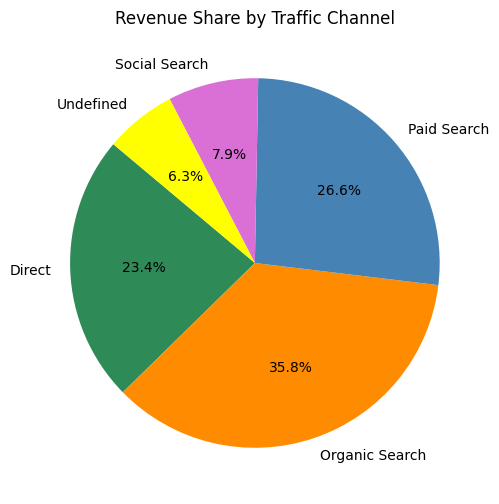

  traffic_channel  product_name  percentage
1  Organic Search         11921       35.54
2     Paid Search          9042       26.96
0          Direct          7800       23.26
3   Social Search          2716        8.10
4       Undefined          2059        6.14


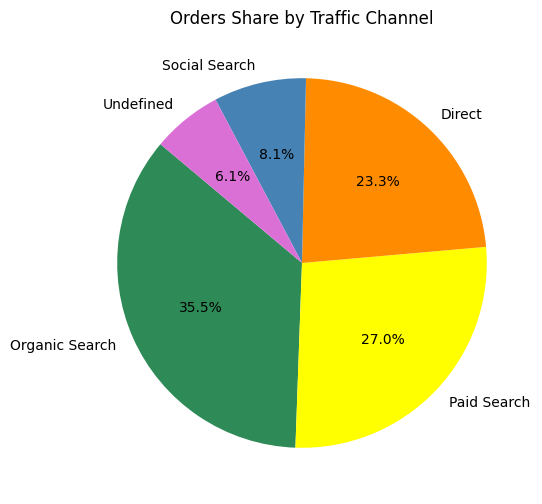

In [ ]:

#----REVENUE BY Traffic Channel---

revenue_by_traffic_channel = sales.groupby("traffic_channel", observed=True)["price"].sum().reset_index()
total_revenue = revenue_by_traffic_channel["price"].sum()
revenue_by_traffic_channel["percentage"] = (revenue_by_traffic_channel["price"] / total_revenue * 100).round(2)
traffic_channel_revenue = revenue_by_traffic_channel.sort_values("percentage", ascending=False)

print(f"\n Device by revenue:\n{traffic_channel_revenue}")

#Visualization pie chart
plt.figure(figsize=(6,6))
plt.pie( revenue_by_traffic_channel["price"], labels=revenue_by_traffic_channel["traffic_channel"], autopct="%1.1f%%", startangle=140, colors=["seagreen", "darkorange", "steelblue", "orchid","yellow"])
plt.title("Revenue Share by Traffic Channel")
plt.show()


#---Orders by Traffic Channel---

orders_by_traffic_channel = sales.groupby("traffic_channel", observed=True)["product_name"].count().reset_index()
total_orders = orders_by_traffic_channel["product_name"].sum()
orders_by_traffic_channel["percentage"] = (orders_by_traffic_channel["product_name"] / total_orders * 100).round(2)
orders_by_traffic_channel = orders_by_traffic_channel.sort_values(ascending=False, by="percentage")

print(orders_by_traffic_channel)

#Visualization pie chart
plt.figure(figsize=(6,6))
plt.pie( orders_by_traffic_channel["product_name"], labels=orders_by_traffic_channel["traffic_channel"], autopct="%1.1f%%", startangle=140, colors=["seagreen", "yellow","darkorange", "steelblue", "orchid"])
plt.title("Orders Share by Traffic Channel")
plt.show()


Different between AOV & Median :
  traffic_channel  Average_revenue  Median_order_value
4       Undefined       971.588635               450.0
0          Direct       960.887615               445.0
1  Organic Search       959.076554               450.0
2     Paid Search       941.279518               430.0
3   Social Search       932.292231               445.0


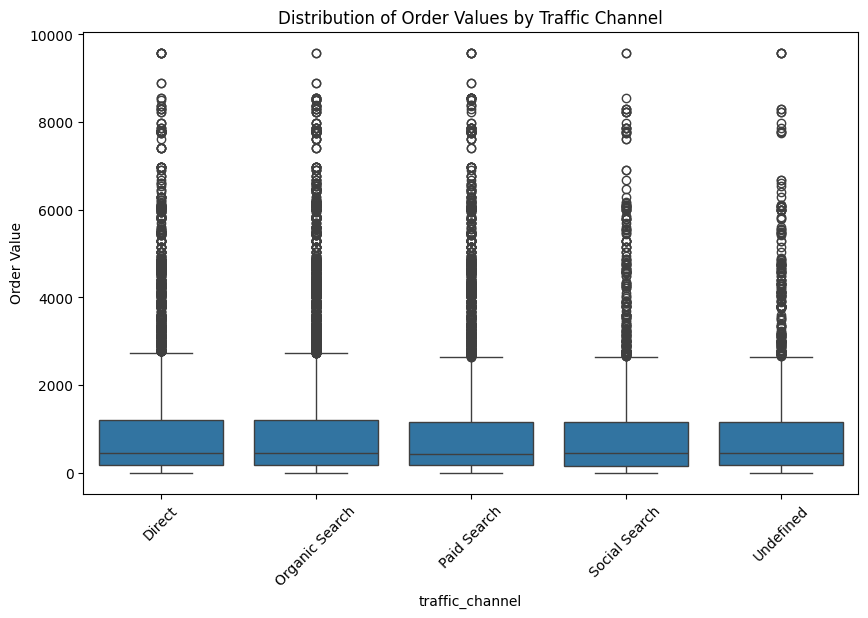

In [ ]:
# --- AOV & Median ---

# Different between AOV & Median for TC(revenue)
stats_by_channel = sales.groupby("traffic_channel",observed=True)["price"].agg(Average_revenue="mean",Median_order_value="median").reset_index()
print(f"Different between AOV & Median :\n{stats_by_channel.sort_values(by="Average_revenue", ascending=False)}")


#Visualization
plt.figure(figsize=(10,6))
sns.boxplot(x="traffic_channel", y="price", data=sales)
plt.title("Distribution of Order Values by Traffic Channel")
plt.ylabel("Order Value")
plt.xticks(rotation=45)
plt.show()




/tmp/ipython-input-136705998.py:22: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_data = heatmap_data.applymap(format_number)


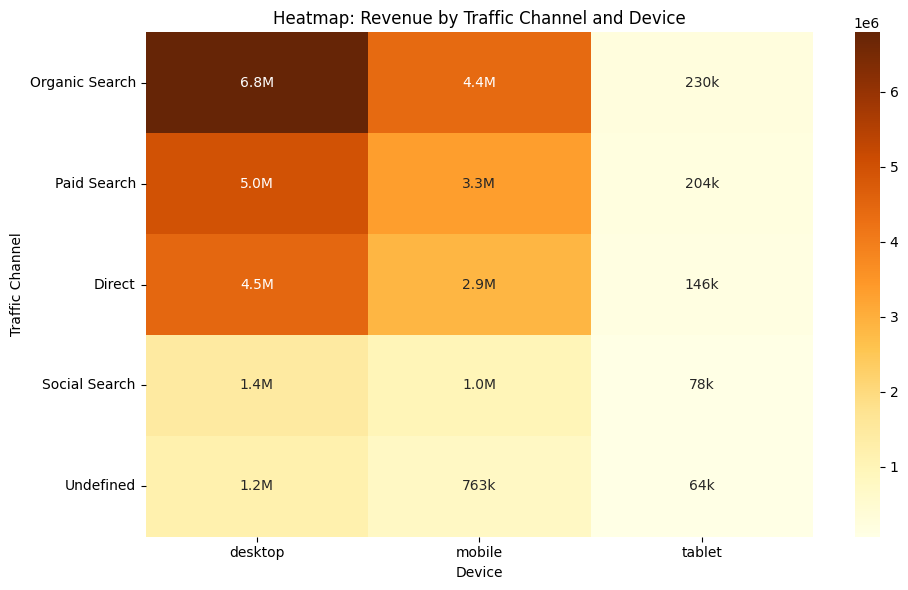

In [ ]:
# --- Device & Traffic Channel ---

# Format func
def format_number(v):
    if v < 1000:
        return f'{int(v)}'
    elif v < 1e6:
        return f'{int(v/1000)}k'
    else:
        return f'{v/1e6:.1f}M'

# Group by device & traffic channel
channel_device = sales.groupby(["traffic_channel", "device"], observed=True).agg(Revenue=("price", "sum"),Orders=("product_name", "count")).reset_index()

# Pivot (Revenue)
heatmap_data = channel_device.pivot(index="traffic_channel", columns="device", values="Revenue")

# Sort values channel by revenue
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]

# Format annot_data
annot_data = heatmap_data.applymap(format_number)
plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, annot=annot_data, fmt="", cmap="YlOrBr")  # fmt="" бо ми вже подали текст
plt.title("Heatmap: Revenue by Traffic Channel and Device")
plt.ylabel("Traffic Channel")
plt.xlabel("Device")
plt.tight_layout()
plt.show()



In [ ]:
#----Sessions Breakdown by Traffic Channel and Device----

# Create clean data about NaN
sales_clean = sales[(sales["traffic_channel"] != "Undefined") & (sales["device"] != "Undefined")].dropna(subset=["traffic_channel", "device"])

# Value for session
sessions_crosstab = pd.crosstab(sales_clean["traffic_channel"],sales_clean["device"],values=sales_clean["session_id"],aggfunc="count")
print(f"\n sessions by channel and device:\n{sessions_crosstab}")

# In Pecrsentage
sessions_pct = pd.pivot_table(sales_clean,values="session_id",index="traffic_channel",columns="device",aggfunc="count",fill_value=0,observed=True)
sessions_pct = sessions_pct.div(sessions_pct.sum(axis=1), axis=0) * 100
print(f"\nPercentage of sessions by channel and device:\n{sessions_pct.round(2)}")





 sessions by channel and device:
device           desktop  mobile  tablet
traffic_channel                         
Direct             47825   31745    1812
Organic Search     72622   49014    2789
Paid Search        55167   37034    2140
Social Search      16288   10988     638
Undefined              0       0       0

Percentage of sessions by channel and device:
device           desktop  mobile  tablet
traffic_channel                         
Direct             58.77   39.01    2.23
Organic Search     58.37   39.39    2.24
Paid Search        58.48   39.26    2.27
Social Search      58.35   39.36    2.29


# Business recomendation
__Revenue vs Orders:__

The revenue structure almost mirrors the order volume structure, meaning traffic channels operate proportionally.

The average order value across channels does not differ significantly, allowing the strategy to be built on balance:

- SEO (Organic Search)- main driver

- Paid Search- premium segments

- Social Search- reach and customer acquisition

__Device Contribution__

No major structural difference across channels:

- Desktop - primary revenue driver

- Mobile - secondary contributor, strong growth potential in Organic and Paid Search

- Tablet - minimal contribution, can be deprioritized

__Strategic Implications for Traffic Channels by Device__

- Focus on Desktop as the core monetization channel

- Invest in Mobile to drive growth and customer retention

- Optimize resources by limiting efforts on Tablet

__Sessions__

Absolute session volumes differ by channel (Organic > Paid > Direct > Social)

Proportional distribution by device is consistent across all channels




# Analysis of registered users
- What percentage of users confirm their email after registration? (Database quality)

- What percentage of users unsubscribe from the mailing list? (Loyalty and retention)

- What revenue is generated by subscribed users vs. those who unsubscribed?

- In which countries are the most subscribed users located?

In [ ]:
# Percentage of email address confirmations
accounts_count = sales["is_registered_user"].nunique()
verified_accounts_count = sales["is_verified"].sum()
verified_percent = (verified_accounts_count / accounts_count * 100).round(2)

print(f"\nNumber of Unique accounts: {accounts_count}")
print(f"\nNumber of Verified accounts: {verified_accounts_count}")
print(f"\nVerified percentage: {verified_percent}%")


Unique accounts: 27945

Verified accounts: 20036

Verified percentage: 71.7%


In [ ]:
# Percentage of unsubscribes from the mailing list
accounts_count = sales["is_registered_user"].nunique()
unsubscribed_accounts_count = sales["is_unsubscribed"].sum()
unsubscribed_percent = (unsubscribed_accounts_count / accounts_count * 100).round(2)
print(f"\nNumber of unique accounts: {accounts_count}")
print(f"\nNumber of unsubscribed accounts: {unsubscribed_accounts_count}")
print(f"\nPercentage of unsubscribed accounts: {unsubscribed_percent}%")


Number of unique accounts: 27945

Number of unsubscribed accounts: 4735

Percentage of unsubscribed accounts: 16.94%


In [ ]:
# ----Sales Metrics by Subscription Status (Subscribed vs Unsubscribed)----
metrics_by_subscription = sales.groupby("is_unsubscribed", observed=True).agg(
        Revenue=("price", "sum"),
        Average_Revenue =("price","mean"),
        Orders=("product_name", "count"),
        AOV=("price", "mean"),
        Median=("price","median")).reset_index()

# Add status for users
metrics_by_subscription["Subscription Status"] = metrics_by_subscription["is_unsubscribed"].map({
    False: "Subscribed users",
    True: "Unsubscribed users"})

# result
print(metrics_by_subscription[["Subscription Status","Orders","Revenue","Average_Revenue","AOV","Median"]].sort_values("Revenue", ascending=False).to_string(index=False))




Subscription Status  Orders   Revenue  Average_Revenue        AOV  Median
   Subscribed users    2334 2150796.9       921.506812 921.506812   395.0
 Unsubscribed users     447  431721.6       965.820134 965.820134   450.0


          Country  Number of registered users
0   United States                       12384
1           India                        2687
2          Canada                        2067
3  United Kingdom                         859
4          France                         553
5           Spain                         536
6          Taiwan                         500
7           China                         490
8         Germany                         490
9           Italy                         386


/tmp/ipython-input-1363590238.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(


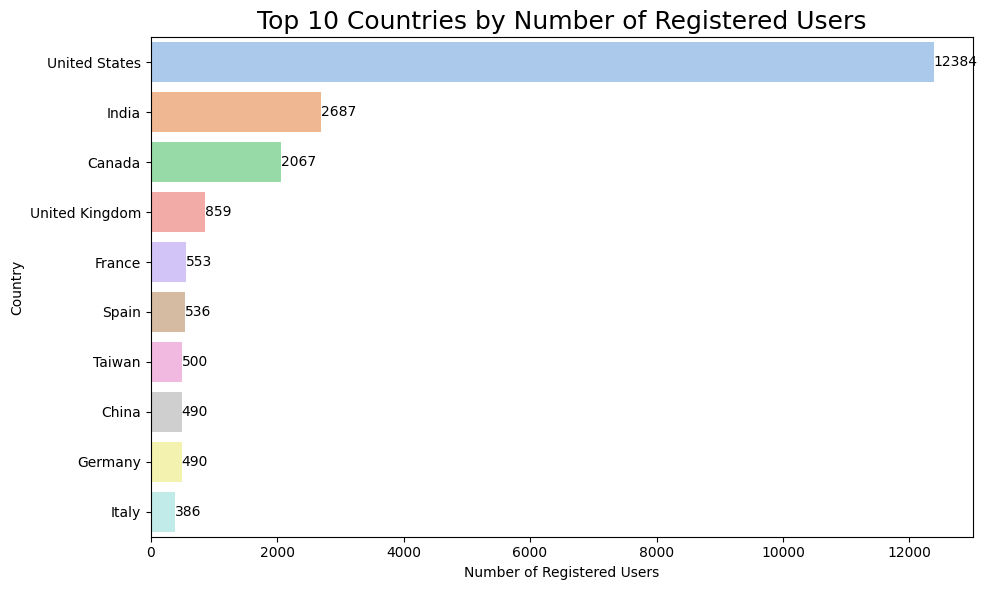

In [ ]:
#----Subscribed user in TOP 10 country-----
# Number of registered users by country
registered_users_by_top_10_country = sales.groupby("country", observed=False)["is_registered_user"].count().sort_values(ascending=False).head(10).reset_index()
registered_users_by_top_10_country.columns = ["Country", "Number of registered users"]
print(registered_users_by_top_10_country)

# Visualization
plt.figure(figsize=(10,6))
ax= sns.barplot(
data=registered_users_by_top_10_country,x="Number of registered users",y="Country",errorbar=("ci", False),
order=registered_users_by_top_10_country["Country"],dodge=False,palette="pastel",legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge')
plt.title("Top 10 Countries by Number of Registered Users", fontsize=18)
plt.xlabel("Number of Registered Users")
plt.ylabel("Country")
plt.tight_layout()
plt.show()



# Business recomendation
__Database quality__

Roughly 7 out of 10 users confirm their email.

__Problem:__ Nearly 30% of users do not confirm their email loss of communication opportunities.

__Recommendation:__

- Optimize the confirmation process (make it simpler, add motivation such as a bonus, discount, or access to exclusive content).

- Use reminders and follow‑up emails for unconfirmed accounts.

- Track verification rates by country/channel to identify weak points.

__Loyalty and retention__

__Problem:__ 16.9% of users unsubscribe every sixth user is lost for email marketing.

__Recommendation:__

- Review the frequency and relevance of newsletter content.

- Segment users: personalized emails based on country, purchase history, and interests.

- Implement A/B testing of subject lines and formats to reduce unsubscribes.

- Add a preference center (allowing users to choose frequency and type of content).

__Revenue Contribution by Subscription Status__

Subscribed users generate 5 times more orders and revenue, but unsubscribed users have a slightly higher average order value.

__Recommendation:__

- Focus primarily on retaining subscribed users  they drive the bulk of transactions.

- For unsubscribed users, leverage alternative communication channels (push notifications, targeted ads), since they still purchase and spend more per transaction.

__Geo about registration user__

__User Base Concentration__  
Most registered and subscribed users are concentrated in a few key countries __(United States, India, Canada)__.

__Recommendation:__ Scale marketing activities in these countries to maximize the impact of the large user base.

__High Revenue per User Markets__  
There are markets with relatively few registrations but high revenue per user __(United Kingdom, France)__.
__Recommendation:__ Invest in acquiring new users in these countries, as each new customer has high value.



#Analysis of sales dynamics




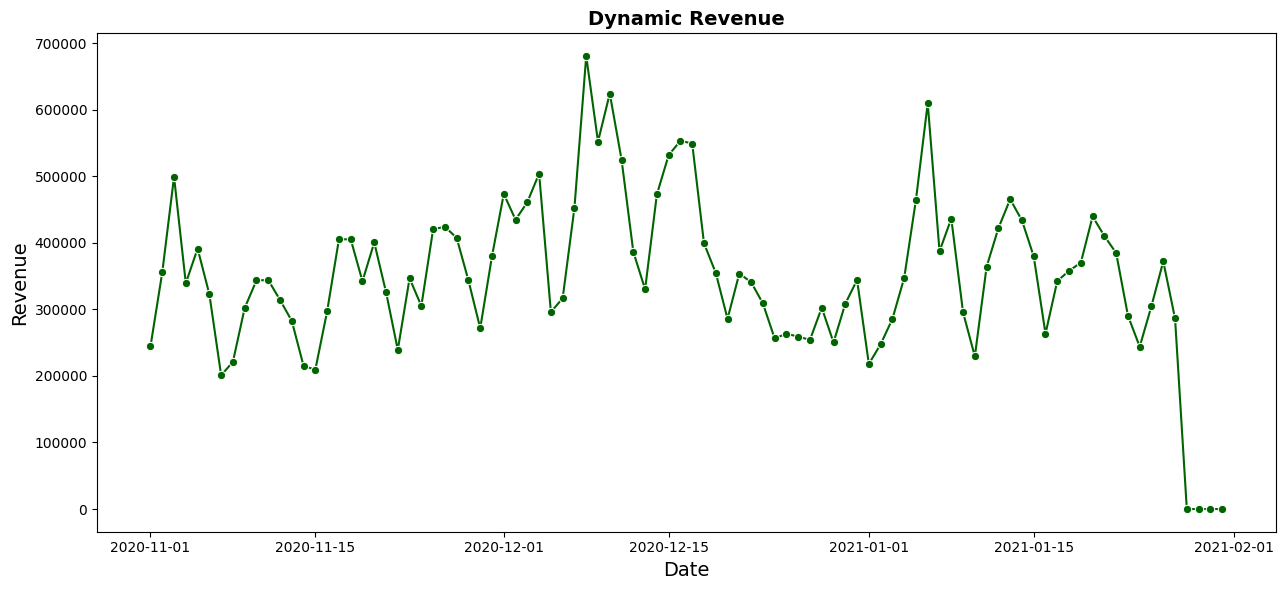

In [ ]:
#---REVENUE DYNAMIC ----

revenue_by_date =sales.groupby("date",observed=True)["price"].sum().reset_index()
#Visualization
plt.figure(figsize=(13,6))
sns.lineplot(data=revenue_by_date,x="date",y="price",color="darkgreen",marker="o")
plt.title("Dynamic Revenue", fontsize=14,fontweight="bold")
plt.xlabel("Date",fontsize=14)
plt.ylabel("Revenue",fontsize=14)
plt.tight_layout()
plt.show()

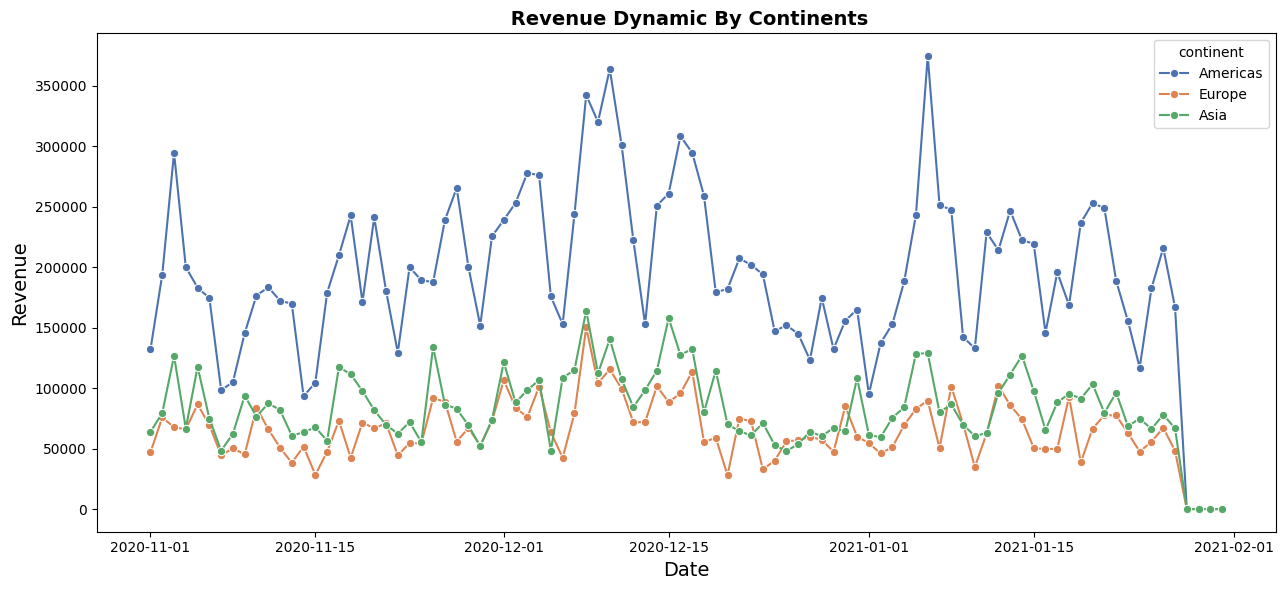

In [ ]:
#--- REVENUE DYNAMIC BY TOP 3 CONTINENT----

continents=["Americas","Europe","Asia"]
filter_by_continent = sales[sales["continent"].isin(continents)].copy()
revenue_by_top_3_continent = filter_by_continent.groupby(["date","continent"], observed=True)["price"].sum().reset_index()
#Visualization
plt.figure(figsize=(13,6))
sns.lineplot(data=revenue_by_top_3_continent,x="date",y="price",hue="continent",hue_order=continents,palette="deep",marker="o")
plt.title(" Revenue Dynamic By Continents", fontsize=14,fontweight="bold")
plt.xlabel("Date",fontsize=14)
plt.ylabel("Revenue",fontsize=14)
plt.tight_layout()
plt.show()






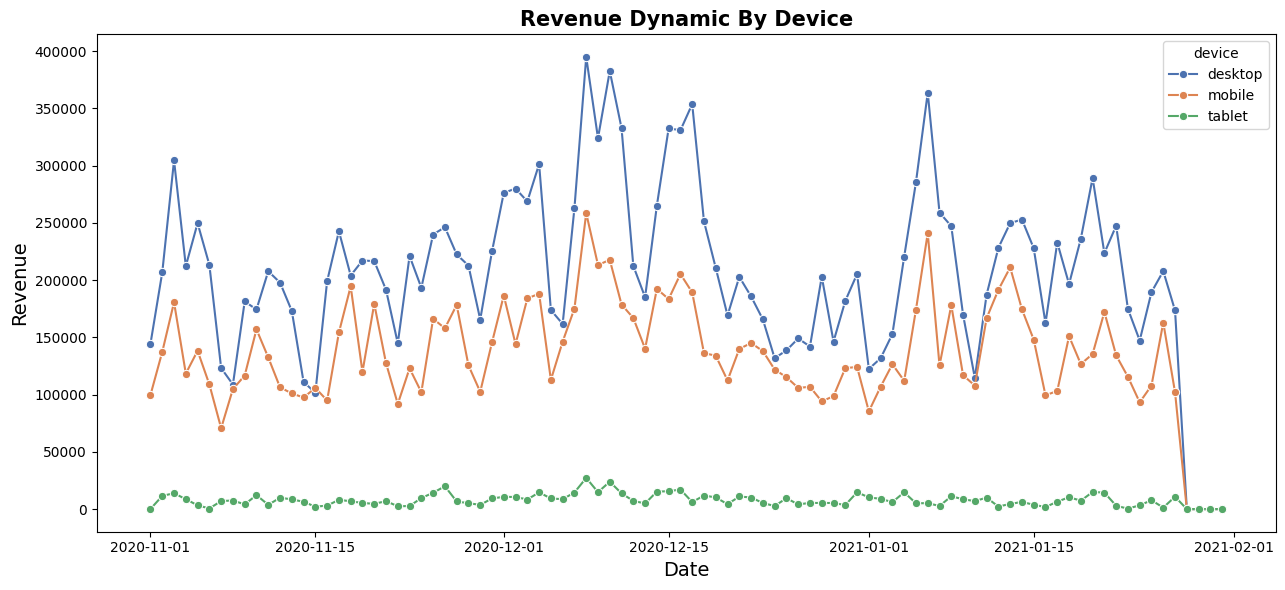

In [ ]:
#----REVENUE DYNAMIC BY DEVICE----
revenue_by_device = sales.groupby(["date","device"], observed=True)["price"].sum().reset_index()
#Visualization
plt.figure(figsize=(13,6))
sns.lineplot(data=revenue_by_device,x="date",y="price",hue="device",palette="deep",marker="o")
plt.title("Revenue Dynamic By Device", fontsize=15,fontweight="bold")
plt.xlabel("Date",fontsize=14)
plt.ylabel("Revenue",fontsize=14)
plt.tight_layout()
plt.show()

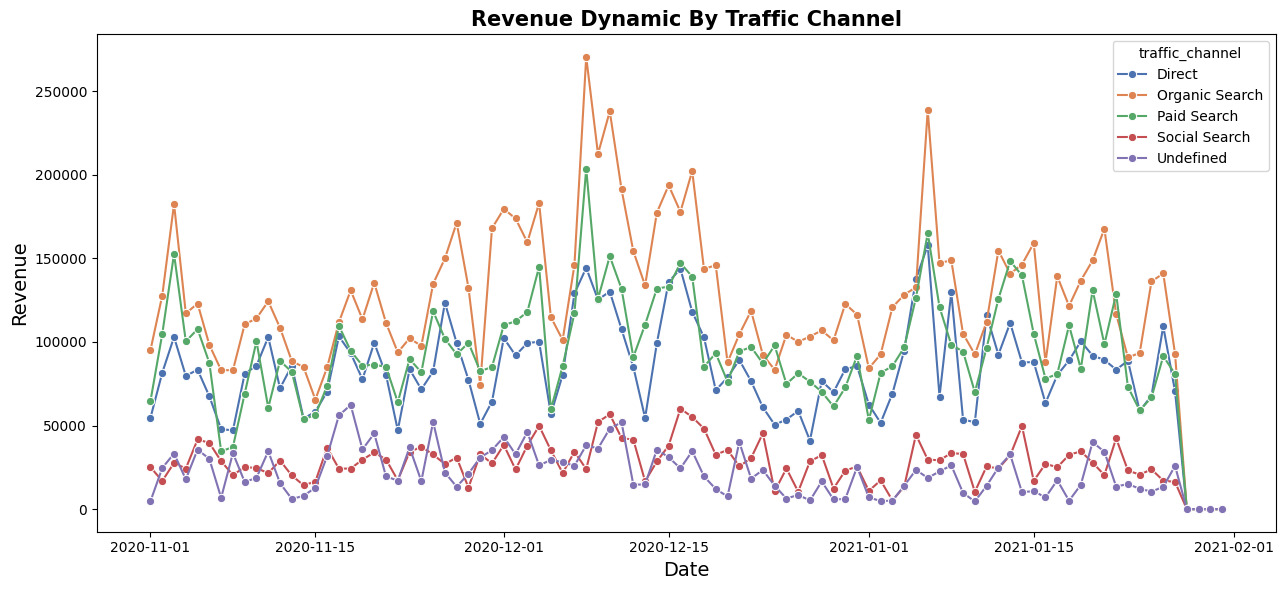

In [ ]:
#----REVENUE DYNAMIC BY TRAFFIC CHANNEL----
revenue_by_traffic_channel = sales.groupby(["date","traffic_channel"], observed=True)["price"].sum().reset_index()
#Visualization
plt.figure(figsize=(13,6))
sns.lineplot(data=revenue_by_traffic_channel,x="date",y="price",hue="traffic_channel",palette="deep",marker="o")
plt.title("Revenue Dynamic By Traffic Channel", fontsize=15,fontweight="bold")
plt.xlabel("Date",fontsize=14)
plt.ylabel("Revenue",fontsize=14)
plt.tight_layout()
plt.show()

# Business recomendation
The highest revenue peaks occur at the end of November-December (likely Black Friday, and pre-holiday promotions). There are distinct waves with peaks and troughs approximately every 2-3 weeks.

Repeated spikes appear in January, but at lower levels this may reflect the post-holiday period with residual demand.

In February, a decline is visible, corresponding to the “low season” after the holidays.

Seasonal campaigns (November-December) deliver the strongest impact budgets should be concentrated during this period.

Paid Search is the most sensitive to seasonality  it is the primary channel to scale during peak periods.

Desktop + Americas = the main drivers of peak revenue.

Mobile should be developed as a promising segment, since it follows the same trend but has potential to grow faster.

#Statistical analysis of interrelationships
- What is the relationship between the number of sessions and total sales across different dates?
- Do global market dynamics drive synchronized revenue changes across regions?
- Is there a statistically significant correlation between the revenue generated by registered and unregistered users?

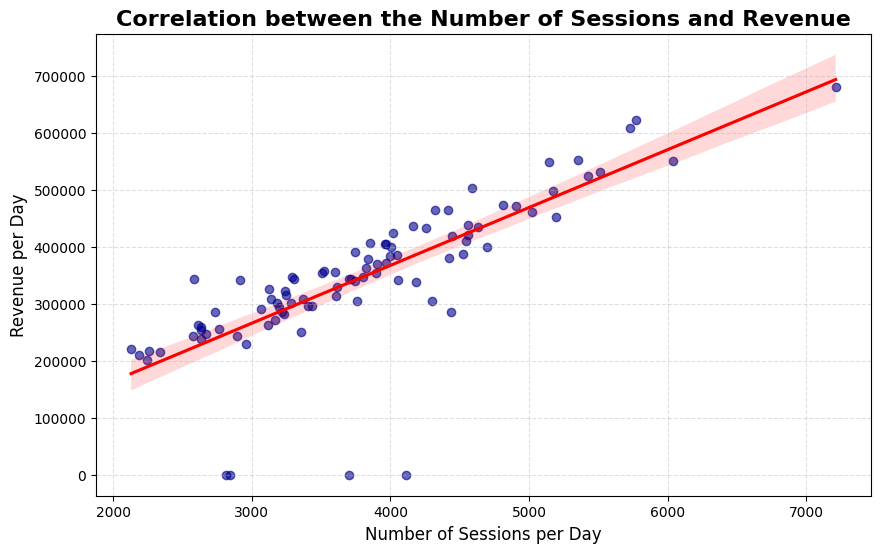

Shapiro-Wilk p-value: 0.0017206798751357067
The data does not have a normal distribution.
p-value: 9.755923586156614e-29 
Spearman Correlation: 0.8653062174563682 
The correlation is statistically significant.


In [ ]:
#-----SESSION & TOTAL SALES (across differen date)----
#--Step 1 visualization--
daily_metrics = sales.groupby("date").agg(total_sessions=("session_id", "count"), total_revenue=("price", "sum")).reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=daily_metrics,x="total_sessions",y="total_revenue",scatter_kws={"color":"darkblue", "alpha":0.6},line_kws={"color":"red"})
plt.title("Correlation between the Number of Sessions and Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Number of Sessions per Day", fontsize=12)
plt.ylabel("Revenue per Day", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

#---Step 2---
# data distribution type
import scipy.stats as stats

stat, p = stats.shapiro(daily_metrics["total_revenue"])
print(f"Shapiro-Wilk p-value: {p}")
if p < 0.05:
    print("The data does not have a normal distribution.")
else:
    print("The data has a normal distribution.")

#---Step 3---
# statistical significance of correlation
r, p_value = stats.spearmanr(daily_metrics["total_sessions"], daily_metrics["total_revenue"])
spearman_corr = daily_metrics["total_sessions"].corr(daily_metrics["total_revenue"], method="spearman")

if p_value < 0.05:
    print("p-value:", p_value, "\nSpearman Correlation:", spearman_corr, "\nThe correlation is statistically significant.")
else:
    print("p-value:", p_value, "\nSpearman Correlation:", spearman_corr, "\nThe correlation is not statistically significant.")


#Conclusions Session & Revenue
The chart visually demonstrates the relationship between session volume and revenue.
Since the data does not follow a normal distribution, we applied Spearman’s correlation.
The results confirm a strong and statistically significant relationship between the number of sessions and revenue.


In [ ]:
#----Correlations by top 3 continent----
from scipy.stats import spearmanr

revenue_df = sales.pivot_table(index="date", columns="continent", values="price",  aggfunc="sum",observed=True)
pairs = [("Americas", "Europe"), ("Americas", "Asia"), ("Europe", "Asia")]

for c1, c2 in pairs:
    df_pair = revenue_df[[c1, c2]].dropna() #dropnal for spearman
    r, p = spearmanr(df_pair[c1], df_pair[c2])

    if p < 0.05:
        print(f"{c1} vs {c2}: Spearman r={r:.2f}, p-value={p:.2e} The correlation is statistically significant.")
    else:
        print(f"{c1} vs {c2}: Spearman r={r:.2f}, p-value={p:.2e} The correlation is not statistically significant.")



Americas vs Europe: Spearman r=0.67, p-value=2.10e-13 The correlation is statistically significant.
Americas vs Asia: Spearman r=0.71, p-value=2.32e-15 The correlation is statistically significant.
Europe vs Asia: Spearman r=0.66, p-value=1.13e-12 The correlation is statistically significant.


# Conclusion for Continent
Revenue trends across continents are strongly correlated, confirming synchronized market behavior.

In [ ]:
#---REGISTERED USER & UNREGISTERED USER---
# Step 1
# data distribution type
registred_acc = sales[sales["is_registered_user"].notnull()] #Verified
reg_acc_revenue = registred_acc.groupby("date")["price"].sum().reset_index(name="total_revenue_by_registred_acc")



not_registed_acc = sales[sales["is_registered_user"].isnull()] #Anonymous
not_reg_acc_revenue = not_registed_acc.groupby("date")["price"].sum().reset_index(name="total_revenue_by_not_registred_acc")

merged_sales = pd.merge(reg_acc_revenue, not_reg_acc_revenue, how="outer", on="date")

for col in ["total_revenue_by_registred_acc", "total_revenue_by_not_registred_acc"]:
    stat, p = stats.shapiro(merged_sales[col])
    print(f"Column: {col}")
    print(f"Shapiro-Wilk p-value: {p}")

    if p < 0.05:
      print("The data does not have a normal distribution.")
    else:
      print("The data has a normal distribution.")



Column: total_revenue_by_registred_acc
Shapiro-Wilk p-value: nan
The data has a normal distribution.
Column: total_revenue_by_not_registred_acc
Shapiro-Wilk p-value: 0.0012184604855253293
The data does not have a normal distribution.


In [ ]:
# Step 2
# Statisticall significant test (not normal distribution )

from scipy.stats import mannwhitneyu

sales_registered = merged_sales["total_revenue_by_registred_acc"].dropna()
sales_not_registered = merged_sales["total_revenue_by_not_registred_acc"].dropna()

u_stat, p_value = mannwhitneyu(sales_registered, sales_not_registered)

if p_value < 0.05:
    print("p-value:", p_value, "\nThe correlation is statistically significant")
else:
    print("p-value:", p_value, "\nThe correlation is not statistically significant")


#  Step 3
#  Aligning the data by dropping rows with missing values for Spearmen test
aligned_sales = merged_sales.dropna(subset=["total_revenue_by_registred_acc","total_revenue_by_not_registred_acc"])

from scipy.stats import spearmanr

r, p = spearmanr(aligned_sales["total_revenue_by_registred_acc"], aligned_sales["total_revenue_by_not_registred_acc"])

if p < 0.05:
   print(f"Registered vs Unregistered: Spearman r={r:.2f}, p-value={p:.2e}  The correlation is statistically significant")
else:
  print(f"Registered vs Unregistered: Spearman r={r:.2f}, p-value={p:.2e} The correlation is not statistically significant")



p-value: 3.8805185465235906e-26 
The correlation is statistically significant
Registered vs Unregistered: Spearman r=0.68, p-value=2.87e-13  The correlation is statistically significant


# Conclusion for registreted & unregistreted users
__Mann-Whitney:__ confirms that the revenue distributions of the two groups are different.

__Spearman:__ shows that despite these differences, revenues move in sync  when registered users’ revenue increases, unregistered users’ revenue tends to increase as well.

__Strength of the relationship (r = 0.68):__ this is a fairly high value, indicating a strong dependence between the segments.

__Business conclusion__

Seasonality and promotions affect both groups simultaneously.

Marketing campaigns targeting one group can have an impact on the other.

Forecasting: data from one group can be used to build predictive models for the other group’s revenue.

At the same time, since Mann-Whitney revealed differences in the distributions, it’s important to account for the specific characteristics of each segment when designing strategies.

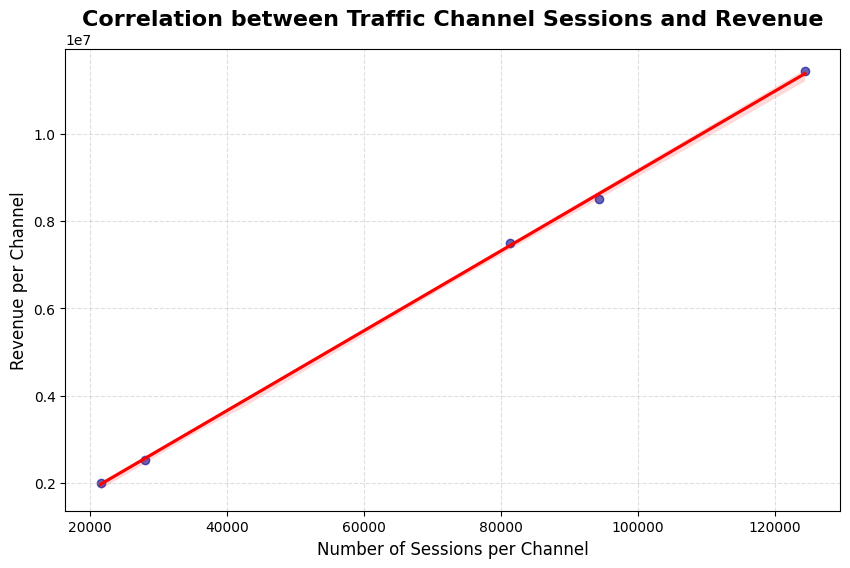

Shapiro-Wilk p-value: 0.4725986400431707
The data has a normal distribution.
p-value: 2.45e-06 
Pearson Correlation: 1.0 
The correlation is statistically significant.


In [ ]:
#---Correlation between Traffic Channel Sessions and Revenue---
#Step 1 visualization
channel_metrics = sales.groupby("traffic_channel",observed=True).agg(total_sessions=("session_id", "count"),total_revenue=("price", "sum")).reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=channel_metrics,x="total_sessions",y="total_revenue",scatter_kws={"color":"darkblue", "alpha":0.6},line_kws={"color":"red"})
plt.title("Correlation between Traffic Channel Sessions and Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Number of Sessions per Channel", fontsize=12)
plt.ylabel("Revenue per Channel", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

# Step 2
# data distribution type
import scipy.stats as stats

stat, p = stats.shapiro(channel_metrics["total_revenue"])
print(f"Shapiro-Wilk p-value: {p}")
if p < 0.05:
    print("The data does not have a normal distribution.")
else:
    print("The data has a normal distribution.")

from scipy.stats import pearsonr

# Step 3
# statistical significance of correlation (Pearson)
r, p_value = pearsonr(channel_metrics["total_sessions"],channel_metrics["total_revenue"])

pearson_corr = channel_metrics["total_sessions"].corr(channel_metrics["total_revenue"], method="pearson")

if p_value < 0.05:
    print("p-value:", f"{p_value:.2e}",
          "\nPearson Correlation:", round(pearson_corr, 2),
          "\nThe correlation is statistically significant.")
else:
    print("p-value:", f"{p_value:.2e}",
          "\nPearson Correlation:", round(pearson_corr, 2),
          "\nThe correlation is not statistically significant.")



# Conclusion for Traffic Channel
Traffic channels differ only in scale (number of sessions), but not in efficiency (revenue per session).

This means that the main driver of revenue is the number of engaged users, rather than differences in session value across channels.

For strategy, it is worth focusing on increasing traffic volume in the most effective channels (for example, Organic), since their conversion into revenue is stable.

In [ ]:
# Saving data for visualization in Tableau
from google.colab import drive
drive.mount("/content/drive")

sales.to_csv("/content/drive/MyDrive/sales_for_tableau.csv", index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
